In [ ]:
# ============================================================
# CELL 1: Download Dataset
# ============================================================
!gdown 1yuAdAo3Gex-HsE1hB3Fa1hL5ucew4Jtb
# Tải file cls_spam_text.csv từ Google Drive về /content/

In [1]:
# ============================================================
# CELL 2: Install Libraries
# ============================================================
!pip install -qq faiss-cpu     # Vector similarity search của Facebook AI
!pip install -qq transformers  # Hugging Face: AutoTokenizer, AutoModel
!pip install -qq pandas        # Xử lý DataFrame
!pip install -qq numpy         # Tính toán array
!pip install -qq scikit-learn  # train_test_split, LabelEncoder, metrics
!pip install -qq tqdm           # Progress bar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 88.7 MB/s eta 0:00:00


In [33]:
# ============================================================
# CELL 3: Import
# ============================================================
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import faiss
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy import stats
from tqdm import tqdm
import matplotlib.pyplot as plt

In [23]:
# ============================================================
# CELL 4: Load Dataset
# ============================================================
# Đọc dataset
df = pd.read_csv("cls_spam_text.csv")
df
# Output: 5572 rows × 2 columns [Category, Message]

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [24]:
print(df.shape, df['Category'].value_counts())

(5572, 2) Category
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
# Tách thành list Python
messages = df['Message'].values.tolist()   # list 5572 chuỗi text
labels   = df['Category'].values.tolist()  # list 5572 nhãn 'ham'/'spam'

In [5]:
# ============================================================
# CELL 5: Load Embedding Model
# ============================================================
MODEL_NAME = 'intfloat/multilingual-e5-base'

In [6]:
# AutoTokenizer: chuyển text → token IDs (subword tokenization)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [7]:
# AutoModel: load trọng số XLM-RoBERTa đã fine-tune cho embedding
model = AutoModel.from_pretrained(MODEL_NAME)

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
# Dùng GPU nếu có (Colab T4) để tăng tốc
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()  # Tắt dropout, chỉ inference

# Output: Using device: cuda | Model name: intfloat/multilingual-e5-base

XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=Tru

In [27]:
print(f'Device: {device}')

Device: cuda


In [9]:
# ============================================================
# CELL 6: Embedding Functions
# ============================================================
def average_pool(last_hidden_states, attention_mask):
    """
    Tính trung bình hidden states, bỏ qua padding tokens.
    last_hidden_states: (batch, seq_len, hidden_dim)
    attention_mask:     (batch, seq_len) — 1=real token, 0=padding
    """
    # masked_fill: đặt giá trị padding → 0 để không tính vào sum
    last_hidden = last_hidden_states.masked_fill(
        ~attention_mask[..., None].bool(), 0.0
    )
    # Chia sum theo số token thực (không phải total seq_len)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]

In [10]:
def encode_text(batch_texts, model, tokenizer, device):
    # Tokenize: chuyển text → tensors (input_ids, attention_mask)
    batch_dict = tokenizer(
        batch_texts,
        max_length=512,   # cắt nếu quá dài
        padding=True,      # pad ngắn hơn cho đồng đều
        truncation=True,
        return_tensors='pt'  # PyTorch tensors
    )
    # Chuyển sang GPU
    batch_dict = {k: v.to(device) for k, v in batch_dict.items()}

    with torch.no_grad():  # Không tính gradient → tiết kiệm VRAM
        outputs = model(**batch_dict)
        batch_embeddings = average_pool(
            outputs.last_hidden_state,
            batch_dict['attention_mask']
        )
        # L2-normalize: ||embedding|| = 1 → IP = cosine similarity
        batch_embeddings = F.normalize(batch_embeddings, p=2, dim=1)
    return batch_embeddings.cpu().numpy()

In [11]:
def get_embeddings(texts, model, tokenizer, device, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i+batch_size]

        # E5 QUAN TRỌNG: thêm prefix "passage:" cho văn bản cần lưu vào index
        # Nếu là query tìm kiếm, dùng prefix "query:"
        batch_with_prefix = [f"passage: {t}" for t in batch_texts]

        batch_emb = encode_text(batch_with_prefix, model, tokenizer, device)
        embeddings.append(batch_emb)

    return np.vstack(embeddings)  # Ghép tất cả batch lại: (5572, 768)

In [12]:
# ============================================================
# CELL 7: Encode Labels + Generate Embeddings
# ============================================================
# Encode nhãn: 'ham' → 0, 'spam' → 1
le = LabelEncoder()
y = le.fit_transform(labels)
print(le.classes_)  # ['ham' 'spam']

['ham' 'spam']


In [13]:
# Tạo embeddings cho toàn bộ 5572 tin nhắn
X_embeddings = get_embeddings(messages, model, tokenizer, device)
print(X_embeddings.shape)  # (5572, 768)

Generating embeddings: 100%|██████████| 175/175 [00:24<00:00,  7.18it/s]

(5572, 768)


In [18]:
# ============================================================
# CELL 8: Create Metadata
# ============================================================
metadata = [
    {'id': i, 'message': msg, 'label': lbl, 'label_encoded': y[i]}
    for i, (msg, lbl) in enumerate(zip(messages, labels))
]
print(f"Metadata: {len(metadata)} docs")

Metadata: 5572 docs


In [14]:
# ============================================================
# CELL 9: Train/Test Split
# ============================================================
TEST_SIZE = 0.1
SEED = 42

In [15]:
train_indices, test_indices = train_test_split(
    range(len(messages)),
    test_size=TEST_SIZE,
    stratify=y,          # Giữ tỷ lệ ham/spam đồng đều ở 2 tập
    random_state=SEED
)

In [19]:
# ✅ Tên biến đúng là X_train_emd (có trong notebook)
X_train_emd = X_embeddings[train_indices]   # (5014, 768)
X_test_emd  = X_embeddings[test_indices]    # (558, 768)
y_train = y[train_indices]
y_test  = y[test_indices]

In [20]:
print(f"Train: {len(X_train_emd)} | Test: {len(X_test_emd)}")
print(f"Train dist: {np.bincount(y_train)}")
print(f"Test  dist: {np.bincount(y_test)}")

Train: 5014 | Test: 558
Train dist: [4342  672]
Test  dist: [483  75]


In [21]:
train_metadata = [metadata[i] for i in train_indices]
test_metadata  = [metadata[i] for i in test_indices]

# Phân bổ train: [4342 ham, 672 spam] | test: [483 ham, 75 spam]

In [28]:
# ============================================================
# CELL 10: Build FAISS Index
# ============================================================
embedding_dim = X_train_emd.shape[1]
index = faiss.IndexFlatIP(embedding_dim)           # Inner Product = Cosine (normalized)
index.add(X_train_emd.astype('float32'))
print(f"FAISS index total: {index.ntotal}")        # 5014

FAISS index total: 5014


In [32]:
# ============================================================
# CELL 11: KNN Prediction
# ============================================================
def knn_predict(index, X_test, y_train, K=5):
  """
    Dự đoán nhãn cho tập test bằng KNN qua FAISS.

    Args:
        index   : FAISS index đã add train embeddings
        X_test  : (n_test, dim) numpy float32
        y_train : (n_train,) nhãn số của train
        K       : số láng giềng gần nhất
    Returns:
        y_pred  : (n_test,) nhãn dự đoán
  """

  # Tìm K nearest neighbors cho toàn bộ test set (một lần, hiệu quả)
  distances, indices = index.search(
    X_test.astype('float32'), K
  )
  # distances: (n_test, K) — inner product scores (cao = gần hơn)
  # indices:   (n_test, K) — chỉ số trong X_train

  y_pred = []
  for i in range(len(X_test)):
    # Lấy K nhãn của K láng giềng
    neighbor_labels = y_train[indices[i]]
    # Majority vote: nhãn nào xuất hiện nhiều nhất
    voted = stats.mode(neighbor_labels, keepdims=True).mode[0]
    y_pred.append(voted)

  return np.array(y_pred)

# Chạy dự đoán trên tập test
K = 5
y_pred = knn_predict(index, X_test_emd, y_train, K=K)

In [34]:
# ============================================================
# CELL 12: Evaluate   ← BỔ SUNG MỚI
# ============================================================
# 1. Accuracy tổng thể
acc = accuracy_score(y_test, y_pred)
print(f"\n=== KNN Spam Classifier (K={K}) ===")
print(f"Accuracy: {acc*100:.2f}%\n")


=== KNN Spam Classifier (K=5) ===
Accuracy: 99.10%



In [35]:
# 2. Classification Report: Precision, Recall, F1 cho từng lớp
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_   # ['ham', 'spam']
))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       483
        spam       1.00      0.93      0.97        75

    accuracy                           0.99       558
   macro avg       0.99      0.97      0.98       558
weighted avg       0.99      0.99      0.99       558



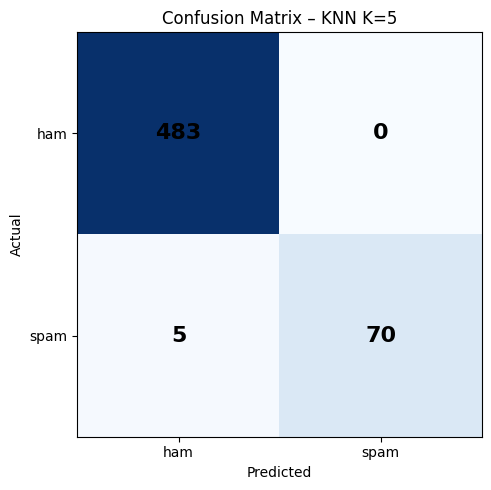

In [36]:
# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(le.classes_); ax.set_yticklabels(le.classes_)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix – KNN K={K}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

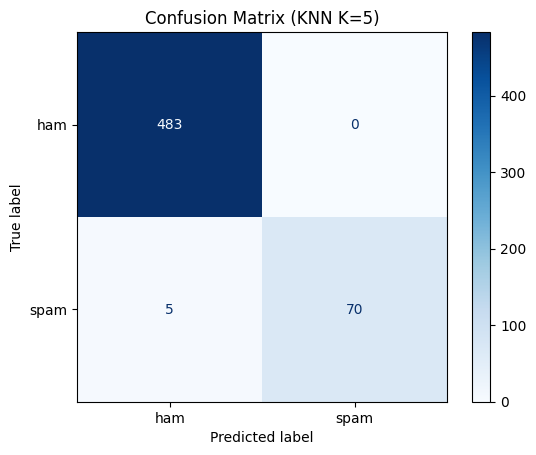

In [37]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (KNN K={K})')
plt.show()